# Swarm Decomposition (SWD)

This notebook introduces **Swarm Decomposition (SWD)** — a non-stationary
signal analysis method that uses *swarm intelligence* rather than empirical
sifting (EMD) or a joint variational problem (VMD).

## Why swarm intelligence?

Biological swarms solve hard tasks (hunting, flocking) through simple local
rules.  SWD turns that idea into a signal filter:

- the **input** is the path of a virtual *prey*;
- a **swarm** of agents chases the prey under driving + cohesion forces;
- the swarm’s collective trajectory is the **filter output**.

Under the right hunting parameters the output isolates a single oscillatory
component.  Repeating the process on the residual yields a full decomposition.

**Reference**

> G. K. Apostolidis, L. J. Hadjileontiadis.  
> *Swarm decomposition: A novel signal analysis using swarm intelligence.*  
> Signal Processing, 132:40–50, 2017.  
> https://doi.org/10.1016/j.sigpro.2016.09.004


## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import hann

from pysdkit import SWD, swd
from pysdkit._osd.swd import swf_params_from_frequency, bandpass_swf

print(SWD())

Swarm Decomposition (SWD)


## 2. Core idea

### 2.1 Swarm filtering (SwF)

Each agent $i$ has position $p_i[n]$ and velocity $v_i[n]$.  Two forces act:

$$
F^{\mathrm{Dr}}_{i}[n] = p_{\mathrm{prey}}[n] - p_i[n-1]
\qquad\text{(drive toward the prey / input)}
$$

$$
F^{\mathrm{Coh}}_{i}[n]
=
\frac{1}{M-1}
\sum_{j\neq i}
f\!\big(p_i[n-1]-p_j[n-1]\big),
\quad
f(d)=-\mathrm{sgn}(d)\,\ln\frac{|d|}{d_{\mathrm{cr}}}
$$

(attract when farther than $d_{\mathrm{cr}}$, repel when closer).  Agents are
updated with flexibility $\delta$, and the filter output is a scaled sum of
positions.

### 2.2 Parameter map (from a genetic algorithm)

The authors fit how many agents $M$ and which $\delta$ recover a tone at
normalised frequency $\hat\omega=\omega/\pi$:

$$
M(\hat\omega)=\big\lfloor 33.46\,\hat\omega^{-0.735}-29.1\big\rceil,
\qquad
\delta(\hat\omega)=-1.5\,\hat\omega^{2}+3.454\,\hat\omega-0.01.
$$

Slow modes need a *larger, less flexible* swarm; fast modes need the opposite.

### 2.3 Swarm decomposition (sifting)

1. Smooth the residual spectrum (Welch / Savitzky–Golay) and pick the dominant
   peak above threshold $P_{\mathrm{th}}$.
2. Run **iterative SwF** with $(M,\delta)$ for that peak until consecutive
   outputs change by less than $StD_{\mathrm{th}}$.
3. Align the component (cross-correlation), subtract it, merge repeats of the
   same band.
4. Stop when no significant peak remains.

`P_th` controls coarseness: larger → fewer, broader components.


## 3. Visualising the $(M, \delta)$ map

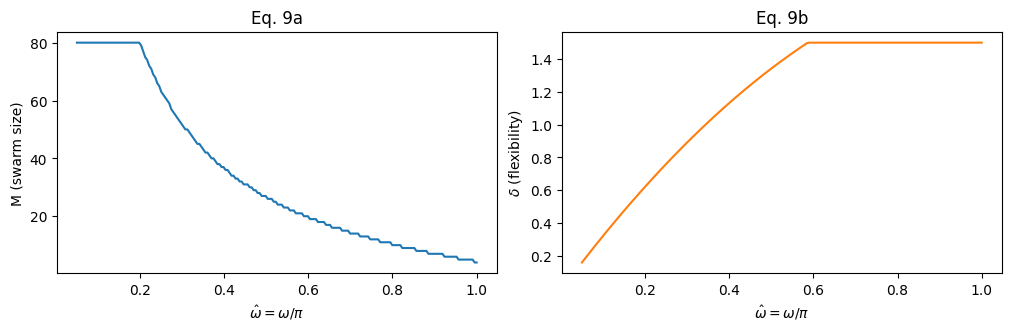

In [ ]:
omega = np.linspace(0.05, 1.0, 200)
Ms, ds = zip(*[swf_params_from_frequency(w) for w in omega])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)
axes[0].plot(omega, Ms, color="C0")
axes[0].set_xlabel(r"$\hat\omega = \omega / \pi$")
axes[0].set_ylabel("M (swarm size)")
axes[0].set_title("Eq. 9a")

axes[1].plot(omega, ds, color="C1")
axes[1].set_xlabel(r"$\hat\omega = \omega / \pi$")
axes[1].set_ylabel(r"$\delta$ (flexibility)")
axes[1].set_title("Eq. 9b")
plt.show()

## 4. Synthetic example (paper-style atoms)

Three windowed tones at $0.2\pi$, $0.6\pi$ and $0.7\pi$ — the same layout as
`EvaluationSignalGenerator` / `exampleSwD_Synthetic.m`.


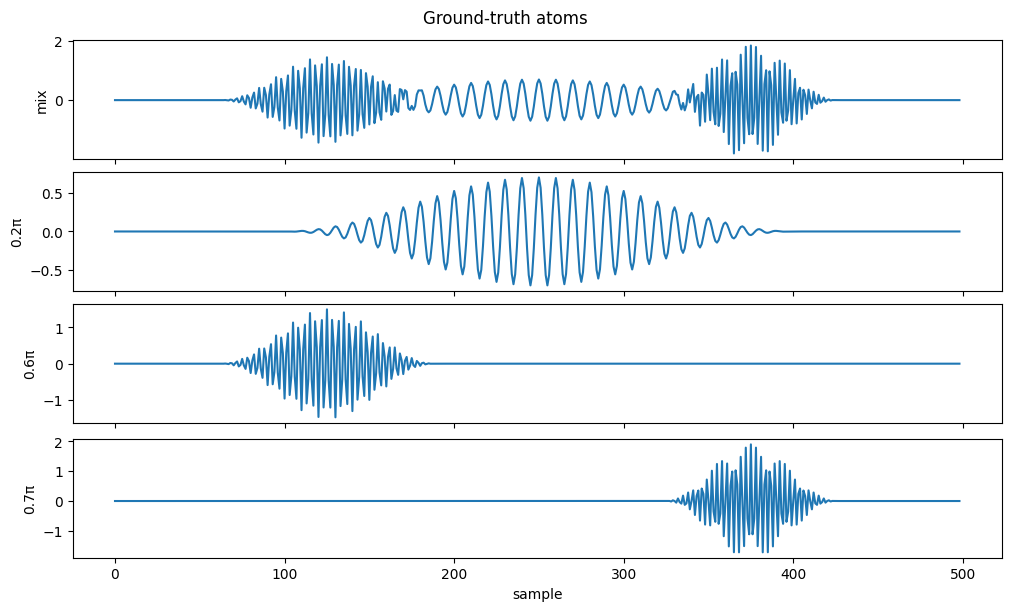

In [ ]:
N = 499
t = np.arange(N)


def atom(t0, f0, T, A):
    win = np.zeros(N)
    a = max(0, int(np.ceil(t0 - T / 2 + 1)) - 1)
    b = min(N, int(np.ceil(t0 + T / 2)))
    w = hann(max(b - a, 1), sym=False)
    win[a : a + len(w)] = w[: len(win[a:b])]
    return A * win * np.cos(f0 * (t - t0))


a1 = atom(250, 0.2 * np.pi, 300, 0.7)
a2 = atom(125, 0.6 * np.pi, 125, 1.5)
a3 = atom(375, 0.7 * np.pi, 100, 1.9)
signal = a1 + a2 + a3

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
axes[0].plot(t, signal)
axes[0].set_ylabel("mix")
axes[1].plot(t, a1)
axes[1].set_ylabel("0.2π")
axes[2].plot(t, a2)
axes[2].set_ylabel("0.6π")
axes[3].plot(t, a3)
axes[3].set_ylabel("0.7π")
axes[3].set_xlabel("sample")
plt.suptitle("Ground-truth atoms")
plt.show()

## 5. Run SWD

In [4]:
swd_c = SWD(P_th=0.05, StD_th=0.05, spectrum="welch", max_components=6, refine=True)
modes, residue, omegas = swd_c.fit_transform(signal, return_all=True)

print("modes shape:", modes.shape)
print("dominant frequencies (ω/π):", np.round(omegas, 3))
recon = modes.sum(axis=0) + residue
print(
    "reconstruction rel. error:",
    np.linalg.norm(recon - signal) / np.linalg.norm(signal),
)

modes shape: (3, 499)
dominant frequencies (ω/π): [0.699 0.199 0.598]
reconstruction rel. error: 1.5567059360665275e-16


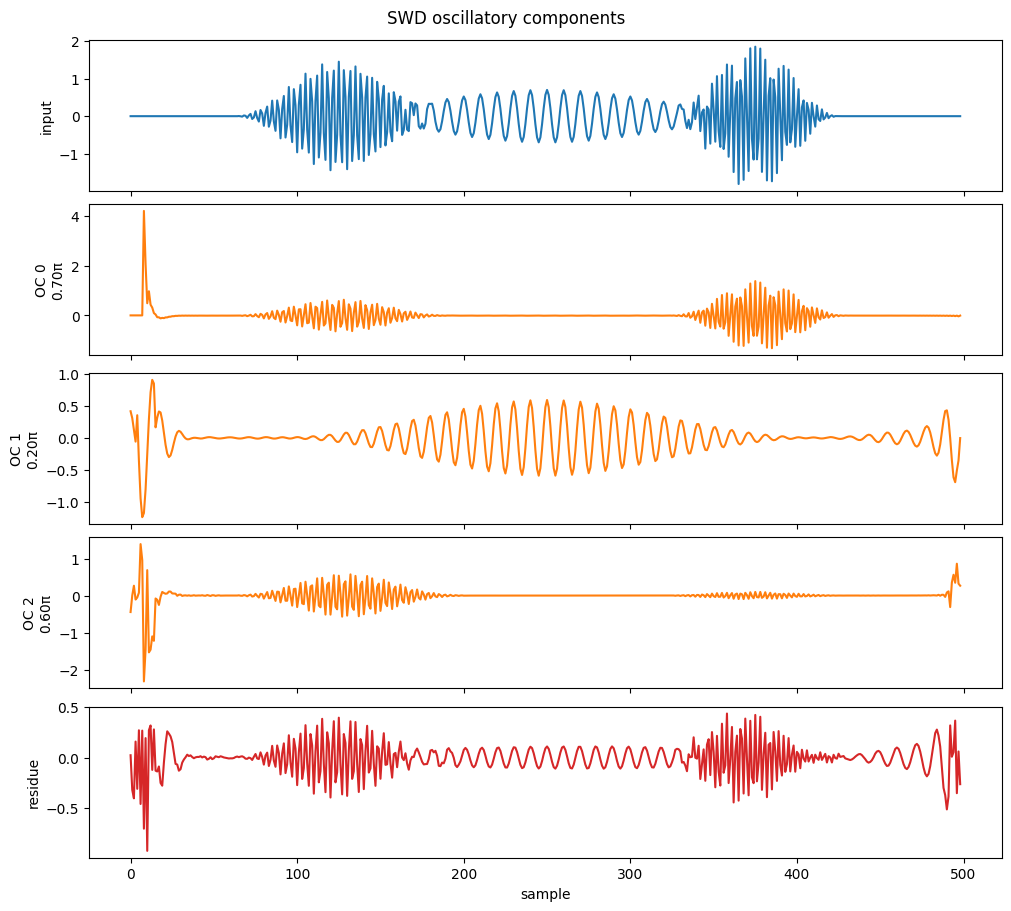

In [5]:
L = modes.shape[0]
fig, axes = plt.subplots(
    L + 2, 1, figsize=(10, 1.8 * (L + 2)), sharex=True, constrained_layout=True
)
axes[0].plot(t, signal, color="C0")
axes[0].set_ylabel("input")
for k in range(L):
    axes[k + 1].plot(t, modes[k], color="C1")
    axes[k + 1].set_ylabel(f"OC {k}\n{omegas[k]:.2f}π")
axes[-1].plot(t, residue, color="C3")
axes[-1].set_ylabel("residue")
axes[-1].set_xlabel("sample")
plt.suptitle("SWD oscillatory components")
plt.show()

## 6. Spectra of the extracted components

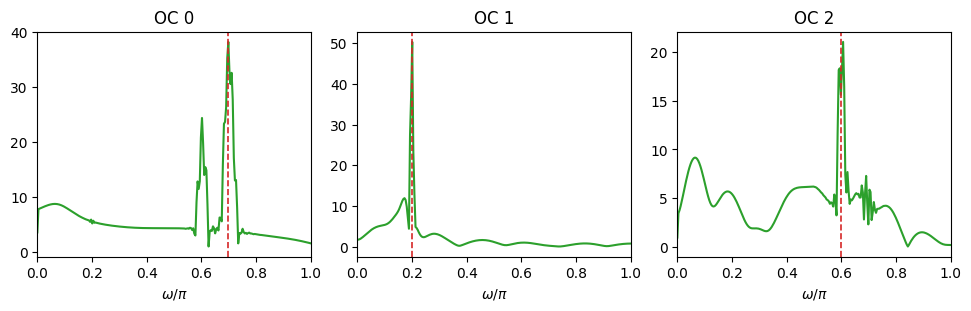

In [ ]:
freqs = np.linspace(0, 1, N // 2 + 1)
fig, axes = plt.subplots(1, L, figsize=(3.2 * L, 3.0), constrained_layout=True)
if L == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    spec = np.abs(np.fft.rfft(modes[k]))
    ax.plot(freqs, spec, color="C2")
    ax.axvline(omegas[k], color="C3", ls="--", lw=1.2)
    ax.set_xlim(0, 1)
    ax.set_title(f"OC {k}")
    ax.set_xlabel(r"$\omega / \pi$")
plt.show()

## 7. Effect of $P_{\mathrm{th}}$ (coarse vs fine)

Larger `P_th` keeps only strong peaks → fewer components.


In [7]:
for pth in (0.05, 0.15, 0.3):
    u, _, om = SWD(P_th=pth, StD_th=0.05, refine=False, max_components=8).fit_transform(
        signal, return_all=True
    )
    print(f"P_th={pth:.2f} → L={u.shape[0]}, ω/π={np.round(om, 3)}")

P_th=0.05 → L=2, ω/π=[0.699 0.199]
P_th=0.15 → L=2, ω/π=[0.699 0.199]
P_th=0.30 → L=2, ω/π=[0.699 0.199]


## 8. API summary

```python
from pysdkit import SWD, swd

swd_c = SWD(P_th=0.05, StD_th=0.05, spectrum="welch")
modes = swd_c.fit_transform(signal)                    # (L, N)
modes, residue, omegas = swd_c.fit_transform(signal, return_all=True)

modes = swd(signal, P_th=0.05, StD_th=0.05)            # functional API
```

| Parameter | Role |
|-----------|------|
| `P_th` | peak threshold → coarse / fine |
| `StD_th` | iterative-SwF stop |
| `spectrum` | `welch` (default), `sg`, or `fft` |
| `refine` | enable time-domain hunting refiner |

### Practical tips

- Start with `P_th≈0.05`, `StD_th≈0.05` (as in the MATLAB synthetic demo).
- Prefer `spectrum="welch"` for smoother peak picking (also used in the updated toolbox examples).
- Very slow modes ($\hat\omega\to 0$) make $M$ large — SWD is usually applied after mild high-pass / resampling, as in the authors’ real-signal demos.


## 9. Takeaways

| | EMD | VMD | SWD |
|--|--|--|--|
| Mechanism | empirical sifting | joint variational | swarm filtering |
| Need $K$? | no | yes | no (peak threshold) |
| Tuning | none / few | $\alpha$, $K$ | $P_{\mathrm{th}}$, $StD_{\mathrm{th}}$ |
| Core prior | extrema symmetry | compact spectrum | GA-mapped swarm response |

SWD is a data-driven alternative when you want oscillatory components without
prescribing their number, and when a bio-inspired filter bank is an appealing
model of the decomposition.
